In [1]:
import sys, os, pathlib, tomllib

sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import poreflow as pf

from logic.segment import (
    build_model,
    shade_regions,
    REGION_TO_STATE,
    STATE_TO_REGION,
    REGION_COLORS,
)

In [2]:
from logic.database import WINDOW_HALF
import numpy as np

def extract_features(steps):
    features = []
    means = steps["mean"].values  # array of per-step means, easy to index

    for i in range(len(steps)):
        ratio = [np.exp(-j**2 / 2.0) for j in range(-WINDOW_HALF, WINDOW_HALF + 1)]

        m2 = means[i-2] if i >= 2 else np.nan
        m1 = means[i-1] if i >= 1 else np.nan
        p1 = means[i+1] if i+1 < len(means) else np.nan
        p2 = means[i+2] if i+2 < len(means) else np.nan

        weighted = (ratio[0]*m2 + ratio[1]*m1 + ratio[2]*means[i] 
                    + ratio[3]*p1 + ratio[4]*p2)

        features.append({
            "mean_current":           means[i],
            "weighted_window_current": weighted,
            "mean_minus2":            m2,
            "mean_minus1":            m1,
            "mean_plus1":             p1,
            "mean_plus2":             p2,
        })

    return pd.DataFrame(features)

# feature_real_df = extract_features(steps)

In [3]:
train_raw = pd.read_csv('data/nanopore_feature_by_IOS.csv')

test_raw = pd.read_csv('data/randomcontrol_feature_by_IOS.csv')

In [4]:
from logic.cnn_brinkerhoff import cnn_sweep

model_4, history_4, X_test_4, y_test_4 = cnn_sweep(
    n_clusters=4, train=train_raw, test=test_raw
    )

n_clusters = 4
model_4.save("my_model.keras")

/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 20, 64)         │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 20, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 20, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 20, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20, 4)          │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 200,964 (785.02 KB)

 Trainable params: 200,324 (782.52 KB)

...

/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


312/312 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8563 - loss: 0.3341 - val_accuracy: 0.8834 - val_loss: 0.2766 - learning_rate: 6.2500e-05
Epoch 31/100
 10/312 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8369 - loss: 0.3716

/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


312/312 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8563 - loss: 0.3320 - val_accuracy: 0.8822 - val_loss: 0.2787 - learning_rate: 6.2500e-05


/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/si

In [36]:
from poreflow.steps import changepoint
from logic.cnn_brinkerhoff import predict_real_event
import scipy.io as sio
import numpy as np
import pandas as pd


mat = sio.loadmat('peptidereads_fig2.mat')
pr = mat['peptidereads'][0, 0]
all_preds = []
variant_str = pr['variant'][0]



for i in range(pr['data'].shape[1]):
    raw      = pr['data'][0, i].flatten()
    pep_start = int(pr['relativeLinkerEnd'][0, i])
    peptide_current = raw[pep_start:]
    
    steps = changepoint.get_steps(peptide_current, sfreq=5000)
    steps = steps[steps['mean'] > 0.2].reset_index(drop=True)  # drop open-pore/noise steps

    if len(steps) == 0:
        continue
    
    features = extract_features(steps)
    pred, probs = predict_real_event(model_4, features, normalize=False)
    all_preds.append({
        'read': i,
        'variant': variant_str[i],
        'pred': pred[:len(steps)],
    })

# summarise per variant
import pandas as pd
rows = []
for r in all_preds:
    for p in r['pred']:
        rows.append({'variant': r['variant'], 'pred_cluster': p})
df_4 = pd.DataFrame(rows)
print(df_4.groupby(['variant', 'pred_cluster']).size().unstack(fill_value=0))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━

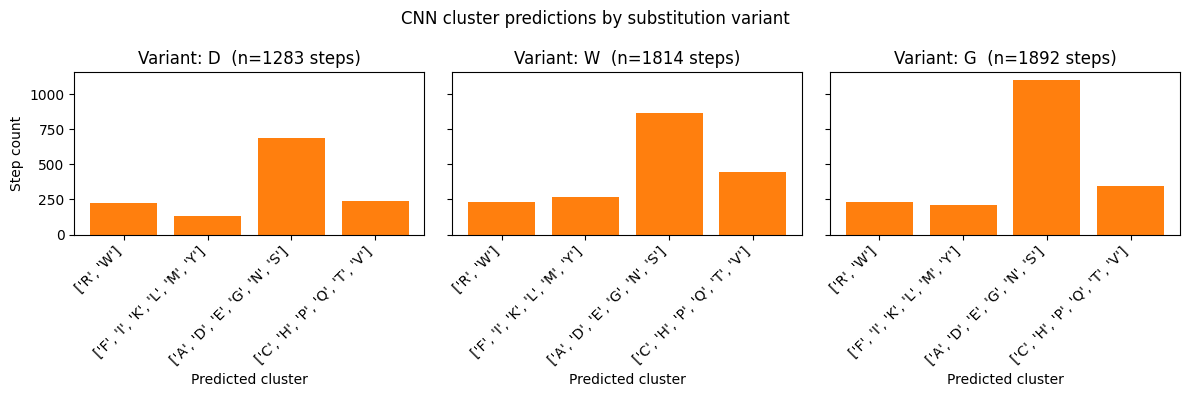

In [45]:
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from logic.clustering_cnn import get_clusters

aa_to_cluster = get_clusters(n_clusters=4)
cluster_to_aas = defaultdict(list)
for aa, cluster in aa_to_cluster.items():
    cluster_to_aas[cluster].append(aa)
tick_labels = [str(sorted(cluster_to_aas[c + 1])) for c in range(4)]


fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, var in zip(axes, ['D', 'W', 'G']):
    subset = df_4[df_4['variant'] == var]['pred_cluster']
    counts = subset.value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_title(f'Variant: {var}  (n={len(subset)} steps)')
    ax.set_xlabel('Predicted cluster')
    # # ax.set_xticks([1, 2, 3, 4])
    # ax.set_xticks([1, 2, 3, 4])
    # ax.set_xticklabels(tick_labels, rotation=45, ha='right')
    # ax.set_xticks([1, 2, 3, 4])
    
    # ax.set_xticklabels(tick_labels)
    # ax.tick_params(axis='x', rotation=45)
    counts = subset.value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_xticks(counts.index)
    ax.set_xticklabels([tick_labels[i-1] for i in counts.index], rotation=45, ha='right')


axes[0].set_ylabel('Step count')
plt.suptitle('CNN cluster predictions by substitution variant')
plt.tight_layout()
plt.show()


In [55]:
import scipy.io as sio
import numpy as np
import pandas as pd
from logic.cnn_brinkerhoff import predict_real_event

mat = sio.loadmat('peptidereads_fig2.mat')
pr = mat['peptidereads'][0, 0]
variant_str = pr['variant'][0]

all_preds = []

for i in range(pr['Peplevels'].shape[1]):
    lev = pr['Peplevels'][0, i][0, 0]

    means     = lev['x_tf_cal'][0, :]
    starts_uf = lev['start'].flatten().astype(int)
    ends_uf   = lev['end'].flatten().astype(int)
    uf_to_f   = lev['uf_to_f'].flatten()
    f_to_tf   = lev['f_to_tf'].flatten().astype(int)

    # step 1: drop levels removed by filter
    valid_uf  = ~np.isnan(uf_to_f)
    starts_f  = starts_uf[valid_uf]
    ends_f    = ends_uf[valid_uf]

    # step 2: merge levels removed by trimming
    n_tf = len(means)
    starts = np.zeros(n_tf, dtype=int)
    ends   = np.zeros(n_tf, dtype=int)
    for tf_idx in range(1, n_tf + 1):
        members = np.where(f_to_tf == tf_idx)[0]
        starts[tf_idx - 1] = starts_f[members].min()
        ends[tf_idx - 1]   = ends_f[members].max()

    steps = pd.DataFrame({'mean': means, 'start_idx': starts, 'end_idx': ends})
    features = extract_features(steps)
    pred, probs = predict_real_event(model_4, features, normalize=False)
    pred_trimmed = pred[:len(steps)]
    
    all_preds.append({
        'read': i,
        'variant': variant_str[i],
        'pred': pred_trimmed,
        'cluster_seq': ''.join(str(c) for c in pred_trimmed),  # e.g. "333323333"
        'n_steps': len(steps),
    })

rows = []
for r in all_preds:
    for p in r['pred']:
        rows.append({'variant': r['variant'], 'pred_cluster': p})
df_4 = pd.DataFrame(rows)
print(df_4.groupby(['variant', 'pred_cluster']).size().unstack(fill_value=0))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━

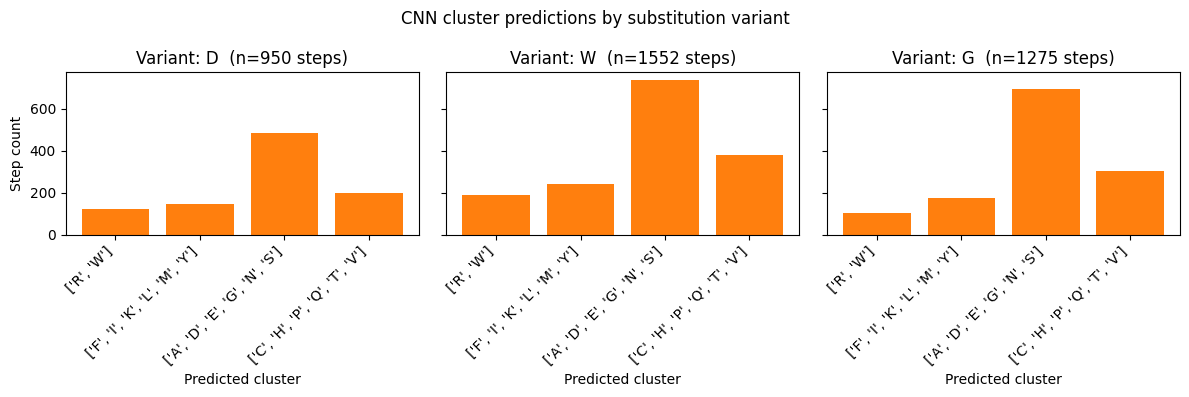

In [50]:
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from logic.clustering_cnn import get_clusters

aa_to_cluster = get_clusters(n_clusters=4)
cluster_to_aas = defaultdict(list)
for aa, cluster in aa_to_cluster.items():
    cluster_to_aas[cluster].append(aa)
tick_labels = [str(sorted(cluster_to_aas[c + 1])) for c in range(4)]


fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, var in zip(axes, ['D', 'W', 'G']):
    subset = df_4[df_4['variant'] == var]['pred_cluster']
    counts = subset.value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_title(f'Variant: {var}  (n={len(subset)} steps)')
    ax.set_xlabel('Predicted cluster')
    # # ax.set_xticks([1, 2, 3, 4])
    # ax.set_xticks([1, 2, 3, 4])
    # ax.set_xticklabels(tick_labels, rotation=45, ha='right')
    # ax.set_xticks([1, 2, 3, 4])
    
    # ax.set_xticklabels(tick_labels)
    # ax.tick_params(axis='x', rotation=45)
    counts = subset.value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_xticks(counts.index)
    ax.set_xticklabels([tick_labels[i-1] for i in counts.index], rotation=45, ha='right')


axes[0].set_ylabel('Step count')
plt.suptitle('CNN cluster predictions by substitution variant')
plt.tight_layout()
plt.show()


In [54]:
# print sequences per variant
for var in ['D', 'W', 'G']:
    print(f'\n=== Variant {var} ===')
    for r in all_preds:
        if r['variant'] == var:
            print(f"  read {r['read']:3d} ({r['n_steps']:2d} steps): {r['cluster_seq']}")



=== Variant D ===
  read   0 (11 steps): 33333333333
  read   1 (29 steps): 33333333333333333333
  read   2 (12 steps): 333333333333
  read   3 (14 steps): 33333333333333
  read   4 (18 steps): 333333333333333333
  read   5 (14 steps): 33333333333333
  read   6 ( 8 steps): 33333333
  read   7 (16 steps): 3333333333333333
  read   8 ( 7 steps): 3333333
  read   9 (23 steps): 33333333333333333333
  read  10 (10 steps): 3333333333
  read  11 (20 steps): 33333333333333333333
  read  12 ( 5 steps): 33333
  read  13 (12 steps): 333333333333
  read  14 (17 steps): 33333333333333333
  read  15 (16 steps): 3333333333333333
  read  16 (12 steps): 333333333333
  read  17 (10 steps): 3333333333
  read  18 (23 steps): 33333333333333333333
  read  19 (10 steps): 3333333333
  read  20 (16 steps): 3333333333333333
  read  21 (11 steps): 33333333333
  read  22 (14 steps): 33333333333333
  read  23 ( 7 steps): 3333333
  read  24 (13 steps): 3333333333333
  read  25 (16 steps): 3333333333333333
  read  

In [22]:
from logic.cnn_brinkerhoff import cnn_sweep

model_7, history_7, X_test_7, y_test_7 = cnn_sweep(
    n_clusters=7, train=train_raw, test=test_raw
    )

n_clusters = 7

/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 20, 64)         │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 20, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 20, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 20, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 20, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20, 7)          │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,159 (785.78 KB)

 Trainable params: 200,519 (783.28 KB)

...

/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


312/312 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6869 - loss: 0.7032 - val_accuracy: 0.7239 - val_loss: 0.6260 - learning_rate: 2.5000e-04
Epoch 17/100
 10/312 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6941 - loss: 0.6820

/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


312/312 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.6885 - loss: 0.7014 - val_accuracy: 0.6973 - val_loss: 0.6777 - learning_rate: 2.5000e-04


/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


In [30]:
from poreflow.steps import changepoint
from logic.cnn_brinkerhoff import predict_real_event
import scipy.io as sio
import numpy as np
import pandas as pd


mat = sio.loadmat('peptidereads_fig2.mat')
pr = mat['peptidereads'][0, 0]
all_preds = []
variant_str = pr['variant'][0]



for i in range(pr['data'].shape[1]):
    raw      = pr['data'][0, i].flatten()
    pep_start = int(pr['relativeLinkerEnd'][0, i])
    peptide_current = raw[pep_start:]
    
    steps = changepoint.get_steps(peptide_current, sfreq=5000)
    steps = steps[steps['mean'] > 0.2].reset_index(drop=True)  # drop open-pore/noise steps
    if len(steps) == 0:
        continue
    
    features = extract_features(steps)
    pred, probs = predict_real_event(model_7, features, normalize=False)
    all_preds.append({
        'read': i,
        'variant': variant_str[i],
        'pred': pred[:len(steps)],
    })

# summarise per variant
import pandas as pd
rows = []
for r in all_preds:
    for p in r['pred']:
        rows.append({'variant': r['variant'], 'pred_cluster': p})
df = pd.DataFrame(rows)
print(df.groupby(['variant', 'pred_cluster']).size().unstack(fill_value=0))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

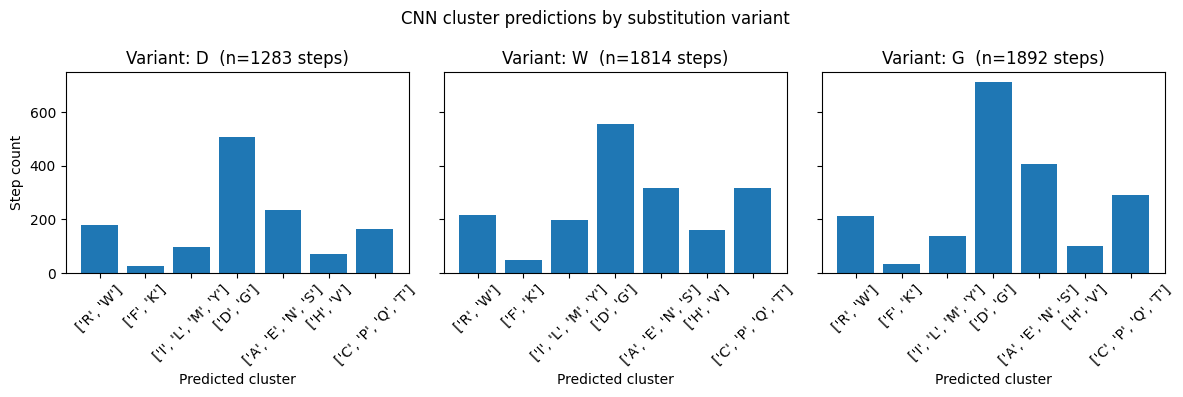

In [33]:
from collections import defaultdict

import matplotlib.pyplot as plt
from logic.clustering_cnn import get_clusters

aa_to_cluster = get_clusters(7)
cluster_to_aas = defaultdict(list)
for aa, cluster in aa_to_cluster.items():
    cluster_to_aas[cluster].append(aa)
tick_labels = [str(sorted(cluster_to_aas[c + 1])) for c in range(n_clusters)]


fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, var in zip(axes, ['D', 'W', 'G']):
    subset = df[df['variant'] == var]['pred_cluster']
    counts = subset.value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_title(f'Variant: {var}  (n={len(subset)} steps)')
    ax.set_xlabel('Predicted cluster')
    ax.set_xticks([1, 2, 3, 4, 5, 6, 7])
    ax.set_xticklabels(tick_labels)
    ax.tick_params(axis='x', rotation=45)
    

axes[0].set_ylabel('Step count')
plt.suptitle('CNN cluster predictions by substitution variant')
plt.tight_layout()
plt.show()
